# Anti-Hubs Study

This notebook inspects the anti-hubs selected by `score-sg` and visualizes them directly on the dataset.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs

from core_sg import CoreSG


## 1. Build a synthetic dataset

The configuration mirrors the existing experiment notebooks so the anti-hub selection is easy to compare.

In [3]:
n_samples = 70000
n_features = 2
centers = 10
k_max = 30
seed = 42

print(
    f"Generating synthetic dataset: n={n_samples}, d={n_features}, centers={centers}, seed={seed}"
)
X, _ = make_blobs(
    n_samples=n_samples,
    n_features=n_features,
    centers=centers,
    random_state=seed,
    cluster_std=0.60,
)
X.shape


Generating synthetic dataset: n=70000, d=2, centers=10, seed=42


(70000, 2)

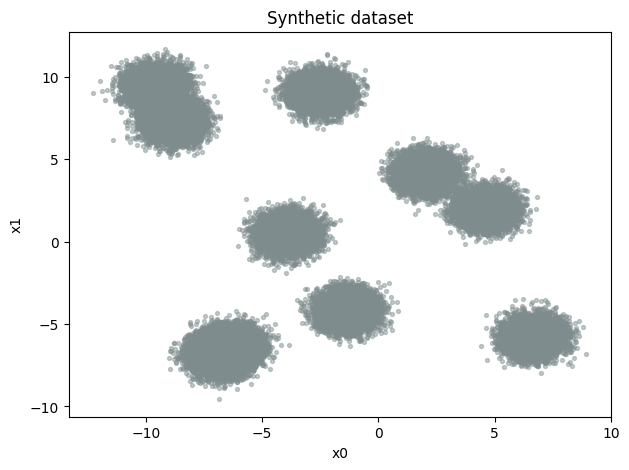

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=8, alpha=0.45, c="#7f8c8d")
plt.title("Synthetic dataset")
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()


## 2. Fit `CoreSG` with `algorithm="score-sg"`

After fitting, the selected anti-hubs are available in the `anti_hubs_` attribute.

In [5]:
score_sg_ = CoreSG(
    metric="euclidean",
    p=2,
    debug=False,
    no_noise=False,
    algorithm="score-sg",
    random_state=seed,
    match_reference_implementation=True,
)

score_sg_.fit(X, k_max=k_max, test_only=True)


/home/gab04/Desktop/core-sg/.venv310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [6]:
anti_hubs = score_sg_.anti_hubs_
print("anti_hubs shape:", anti_hubs.shape)
print("expected sqrt(n):", int(np.floor(np.sqrt(X.shape[0]))))
print("first 20 anti_hubs:", anti_hubs[:20])


anti_hubs shape: (264,)
expected sqrt(n): 264
first 20 anti_hubs: [ 168  362  489 1060 1720 2545 2699 2921 3164 3636 5009 5030 5198 5290
 5335 5572 6116 6195 6560 6603]


## 3. Visualize anti-hubs on the dataset

The anti-hubs are highlighted as red points over the full dataset.

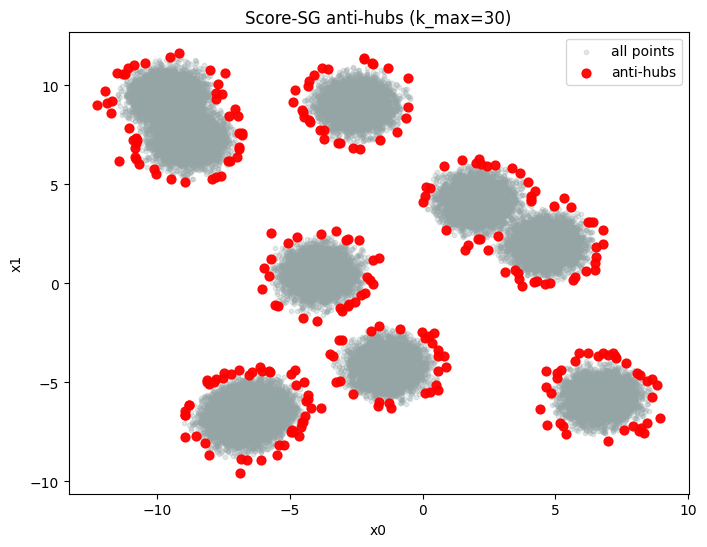

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=10, alpha=0.25, c="#95a5a6", label="all points")
plt.scatter(
    X[anti_hubs, 0],
    X[anti_hubs, 1],
    s=40,
    c="red",
    alpha=0.95,
    label="anti-hubs",
)
plt.title(f"Score-SG anti-hubs (k_max={k_max})")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.show()


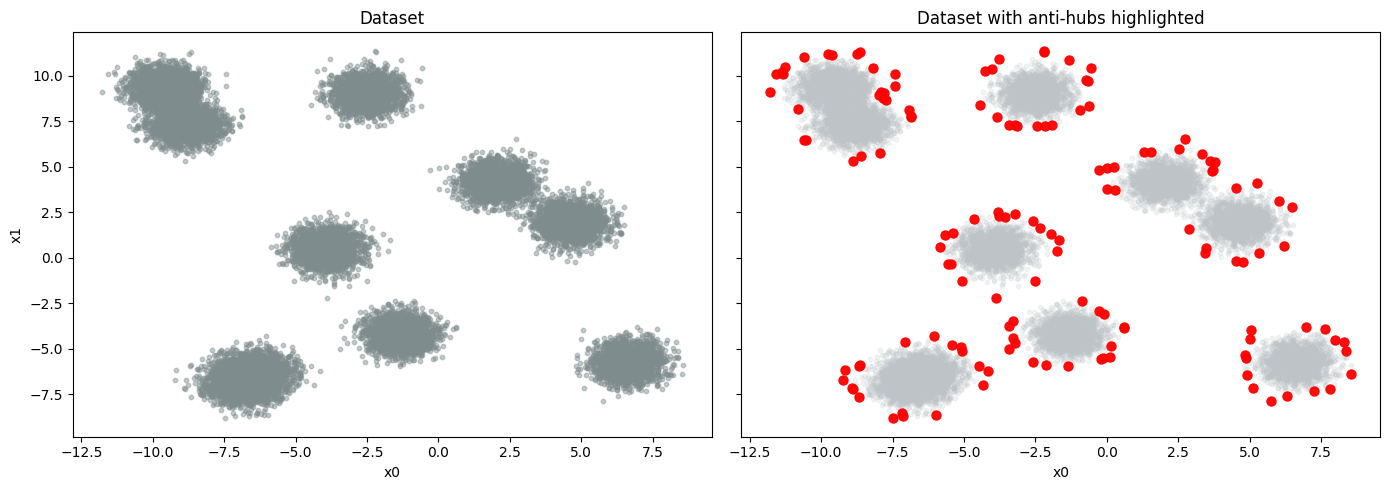

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

axes[0].scatter(X[:, 0], X[:, 1], s=10, alpha=0.45, c="#7f8c8d")
axes[0].set_title("Dataset")
axes[0].set_xlabel("x0")
axes[0].set_ylabel("x1")

axes[1].scatter(X[:, 0], X[:, 1], s=10, alpha=0.18, c="#bdc3c7")
axes[1].scatter(
    X[anti_hubs, 0],
    X[anti_hubs, 1],
    s=42,
    c="red",
    alpha=0.95,
)
axes[1].set_title("Dataset with anti-hubs highlighted")
axes[1].set_xlabel("x0")

plt.tight_layout()
plt.show()
